In [1]:
# importing packages
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import json

from chargers import *
from metrics import *
from graphs import *

## Abortion Experiment

In [2]:
experiment = "abortion" # presidential, plebiscite, or abortion
column_to_predict = 'religion_14'
results_route =  f"../results_dataframes/{experiment}/"

In [3]:
d = {
  "abortodebeserpermitidosoloencasosespeciales":2,
  "abortion should be prohibited in all cases":1,
  "always prohibited":1,
  "abortion should be allowed in cases of special circumstances":2,
  "always be prohibited":1,
  "aborto debe estar permitido en cualquier caso": 3,
  "permitir el aborto en cualquier caso":3,
  "abortion should be permitted in any case":3,
  "abortion should be allowed in any case":3,
  "aborto debe estar siempre prohibido." : 1,
  "aborto debe ser permitido solo en casos especiales":2,
  "abortion should be prohibited except in special cases":2,
  "aborto solo debe estar permitido en casos especiales." : 2,
  "aborto debe estar solo permitido en casos especiales." : 2,
  "aborto debe estar permitido solo en casos especiales." : 2,
  "aborto debe estar permitido en casos especiales.":2,
  "aborto debe solo estar permitido en casos especiales.":2,
  "aborto solo debe solo estar permitido en casos especiales.":2,
  "aborto debe ser una opción para las mujeres en cualquier caso.":3,
  "aborto debe estar siempre permitido.":3,
  "abortion should only be allowed in special cases.": 2,
  "abortion should be allowed only in special cases":2,
  "abortion should be allowed in special cases":2,
  "abortion should be only allowed in special cases":2,
  "abortion should always be prohibited." : 1,
  "abortion should be an option for women in any case.": 3,
  "aborto debe estar siempre prohibido" : 1,
  "aborto solo debe estar permitido en casos especiales" : 2,
  "aborto debe estar solo permitido en casos especiales" : 2,
  "aborto debe estar permitido solo en casos especiales" : 2,
  "aborto debe estar permitido en casos especiales":2,
  "aborto debe solo estar permitido en casos especiales":2,
  "aborto solo debe solo estar permitido en casos especiales":2,
  "aborto debe ser una opción para las mujeres en cualquier caso":3,
  "aborto debe estar siempre permitido":3,
  "abortion should only be allowed in special cases": 2,
  "abortion should always be prohibited" : 1,
  "abortion should be an option for women in any case": 3,
  "siempre prohibido":1,
  "permitido en cualquier caso":3,
  "in special cases":2,
  "en casos especiales":2,
  "prohibido en cualquier caso":1,
  "1":1,
  "2":2,
  "3":3
}

In [4]:
gpt3_json_df = pd.read_csv(results_route + f"{experiment}_chile_chatgpt3_cot.csv")
gpt3_json = data_charger(results_route +"exp_inputs_filtrado.csv", gpt3_json_df, d, prompt_type='cot')
gpt4_json_df = pd.read_csv(results_route + f"{experiment}_chile_chatgpt4_cot.csv")
gpt4_json = data_charger(results_route +"exp_inputs_filtrado.csv", gpt4_json_df, d, prompt_type='cot')
llama_json = data_charger(results_route +"exp_inputs_filtrado.csv", results_route + f"{experiment}_chile_llama_cot.jsonl", d, prompt_type='cot')
mistral_json = data_charger(results_route +"exp_inputs_filtrado.csv", results_route + f"{experiment}_chile_mistral_cot.jsonl", d, prompt_type='cot')
t0_json = data_charger(results_route +"exp_inputs_filtrado.csv", results_route + f"{experiment}_chile_t0_cot.jsonl", d, prompt_type='cot', is_t0=True)
df_rf = pd.read_csv(results_route + f"randomforest_{experiment}_chile.csv")

In [5]:
## Random forest metrics

df_rf = pd.read_csv(results_route + f"randomforest_{experiment}_chile.csv")
# Identificar las columnas de región
region_columns = [col for col in df_rf.columns if col.startswith('region_')]

# Reconstruir la columna original 'nom_region'
df_rf['nom_region'] = df_rf[region_columns].idxmax(axis=1).str.replace('region_', '')

results_rf = metrics_dataset_gen_chile(df_rf, column_to_predict,n_bootstrap=1000, random_seed=42)

/Users/aabeliuk/miniforge3/envs/torch_env/lib/python3.10/site-packages/scipy/spatial/distance.py:1381: RuntimeWarning: invalid value encountered in divide
  p = p / np.sum(p, axis=axis, keepdims=True)
/Users/aabeliuk/miniforge3/envs/torch_env/lib/python3.10/site-packages/scipy/spatial/distance.py:1382: RuntimeWarning: invalid value encountered in divide
  q = q / np.sum(q, axis=axis, keepdims=True)
/Users/aabeliuk/miniforge3/envs/torch_env/lib/python3.10/site-packages/scipy/spatial/distance.py:1381: RuntimeWarning: invalid value encountered in divide
  p = p / np.sum(p, axis=axis, keepdims=True)
/Users/aabeliuk/miniforge3/envs/torch_env/lib/python3.10/site-packages/scipy/spatial/distance.py:1382: RuntimeWarning: invalid value encountered in divide
  q = q / np.sum(q, axis=axis, keepdims=True)
/Users/aabeliuk/miniforge3/envs/torch_env/lib/python3.10/site-packages/scipy/spatial/distance.py:1381: RuntimeWarning: invalid value encountered in divide
  p = p / np.sum(p, axis=axis, keepdims=T

In [6]:
llama_json_metrics = metrics_dataset_gen_chile(llama_json, column_to_predict, n_bootstrap=1000, random_seed=42)
llama_json_metrics = llama_json_metrics[llama_json_metrics['Group'] != 'total']


/Users/aabeliuk/Documents/GitHub/fair-llm-surveys/Results_Analysis/Notebooks/metrics.py:260: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options, **bootstrap_kwargs)


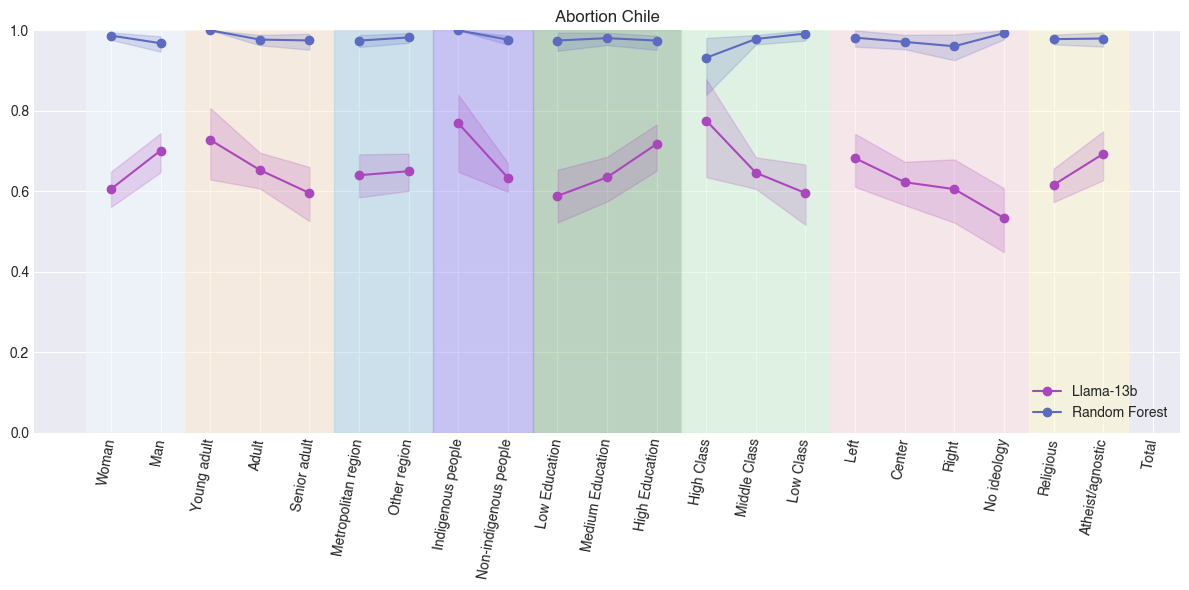

In [7]:
# Colors for each model
modelos_colores = {
    "Random Forest": "#5c6bc0",
    "ChatGPT-4": "#66bb6a",
    "ChatGPT-3.5": "#ff7043",
    "Llama-13b": "#ab47bc",
    "Mistral-Intruct-v0.2": "#ffa726",
    "T-zero": "#f48fb1",
    "Best fine-tuned (F2)": "#90a4ae",
    "Embedding + RandomForest": "#1e88e5"
}

modelos = [llama_json_metrics, results_rf ]
modelos_nombres = ["Llama-13b", "Random Forest"]
sociodemographic_line_plot(modelos, modelos_colores, modelos_nombres, "Abortion Chile")

## Plebiscite Experiment

In [9]:
experiment = "plebiscite" # presidential, plebiscite, or abortion
column_to_predict = 'constitucion_20_a'
results_route =  f"../results_dataframes/{experiment}/"

d = {
    "apruebo" : 1,
    "rechazo" : 2,
    "nulo": 3,
    "approve":1,
    "reject": 2,
    "null":3,
    "approve/s":1,
    "reject/s": 2,
    "null/s":3
}

In [10]:
gpt3_json_df = pd.read_csv(results_route + f"{experiment}_chile_chatgpt3_cot.csv")
gpt3_json = data_charger(results_route +"exp_inputs_filtrado.csv", gpt3_json_df, d, prompt_type='cot')
gpt4_json_df = pd.read_csv(results_route + f"{experiment}_chile_chatgpt4_cot.csv")
gpt4_json = data_charger(results_route +"exp_inputs_filtrado.csv", gpt4_json_df, d, prompt_type='cot')
llama_json = data_charger(results_route +"exp_inputs_filtrado.csv", results_route + f"{experiment}_chile_llama_cot.jsonl", d, prompt_type='cot')
mistral_json = data_charger(results_route +"exp_inputs_filtrado.csv", results_route + f"{experiment}_chile_mistral_cot.jsonl", d, prompt_type='cot')
t0_json = data_charger(results_route +"exp_inputs_filtrado.csv", results_route + f"{experiment}_chile_t0_cot.jsonl", d, prompt_type='cot', is_t0=True)

In [11]:
## Random forest metrics

df_rf = pd.read_csv(results_route + f"randomforest_{experiment}_chile.csv")
# Identificar las columnas de región
region_columns = [col for col in df_rf.columns if col.startswith('region_')]

# Reconstruir la columna original 'nom_region'
df_rf['nom_region'] = df_rf[region_columns].idxmax(axis=1).str.replace('region_', '')

results_rf = metrics_dataset_gen_chile(df_rf, column_to_predict,n_bootstrap=1000, random_seed=42)

/Users/aabeliuk/miniforge3/envs/torch_env/lib/python3.10/site-packages/scipy/spatial/distance.py:1381: RuntimeWarning: invalid value encountered in divide
  p = p / np.sum(p, axis=axis, keepdims=True)
/Users/aabeliuk/miniforge3/envs/torch_env/lib/python3.10/site-packages/scipy/spatial/distance.py:1382: RuntimeWarning: invalid value encountered in divide
  q = q / np.sum(q, axis=axis, keepdims=True)
/Users/aabeliuk/miniforge3/envs/torch_env/lib/python3.10/site-packages/scipy/spatial/distance.py:1381: RuntimeWarning: invalid value encountered in divide
  p = p / np.sum(p, axis=axis, keepdims=True)
/Users/aabeliuk/miniforge3/envs/torch_env/lib/python3.10/site-packages/scipy/spatial/distance.py:1382: RuntimeWarning: invalid value encountered in divide
  q = q / np.sum(q, axis=axis, keepdims=True)
/Users/aabeliuk/miniforge3/envs/torch_env/lib/python3.10/site-packages/scipy/spatial/distance.py:1381: RuntimeWarning: invalid value encountered in divide
  p = p / np.sum(p, axis=axis, keepdims=T

In [12]:
llama_json_metrics = metrics_dataset_gen_chile(llama_json, column_to_predict, n_bootstrap=1000, random_seed=42)
llama_json_metrics = llama_json_metrics[llama_json_metrics['Group'] != 'total']

/Users/aabeliuk/Documents/GitHub/fair-llm-surveys/Results_Analysis/Notebooks/metrics.py:260: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options, **bootstrap_kwargs)


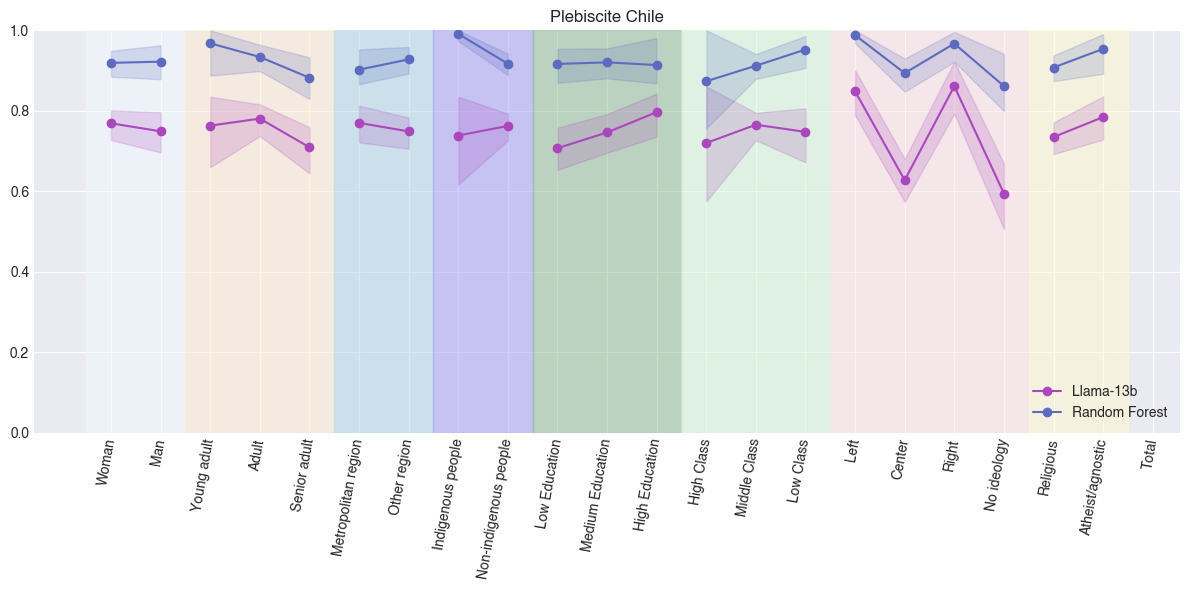

In [13]:
modelos = [llama_json_metrics, results_rf ]
modelos_nombres = ["Llama-13b", "Random Forest"]
sociodemographic_line_plot(modelos, modelos_colores, modelos_nombres, "Plebiscite Chile")

## Presidential Experiment

In [15]:
experiment = "presidential" # presidential, plebiscite, or abortion
column_to_predict = 'elec_pres_144_a'
results_route =  f"../results_dataframes/{experiment}/"
d = {
    "boric" : 1,
    "kast" : 2,
    "nulo": 3,
    "gabriel boric font":1,
    "josé antonio kast rist":2,
    "null":3,
    "none":3,
    "neither":3,
    "voted null": 3,
}

In [16]:
gpt3_json_df = pd.read_csv(results_route + f"{experiment}_chile_chatgpt3_cot.csv")
gpt3_json = data_charger(results_route +"exp_inputs_filtrado.csv", gpt3_json_df, d, prompt_type='cot')
gpt4_json_df = pd.read_csv(results_route + f"{experiment}_chile_chatgpt4_cot.csv")
gpt4_json = data_charger(results_route +"exp_inputs_filtrado.csv", gpt4_json_df, d, prompt_type='cot')
llama_json = data_charger(results_route +"exp_inputs_filtrado.csv", results_route + f"{experiment}_chile_llama_cot.jsonl", d, prompt_type='cot')
mistral_json = data_charger(results_route +"exp_inputs_filtrado.csv", results_route + f"{experiment}_chile_mistral_cot.jsonl", d, prompt_type='cot')
t0_json = data_charger(results_route +"exp_inputs_filtrado.csv", results_route + f"{experiment}_chile_t0_cot.jsonl", d, prompt_type='cot', is_t0=True)

In [17]:
## Random forest metrics

df_rf = pd.read_csv(results_route + f"randomforest_{experiment}_chile.csv")
# Identificar las columnas de región
region_columns = [col for col in df_rf.columns if col.startswith('region_')]

# Reconstruir la columna original 'nom_region'
df_rf['nom_region'] = df_rf[region_columns].idxmax(axis=1).str.replace('region_', '')

results_rf = metrics_dataset_gen_chile(df_rf, column_to_predict,n_bootstrap=1000, random_seed=42)

/Users/aabeliuk/miniforge3/envs/torch_env/lib/python3.10/site-packages/scipy/spatial/distance.py:1391: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(js / 2.0)
/Users/aabeliuk/miniforge3/envs/torch_env/lib/python3.10/site-packages/scipy/spatial/distance.py:1381: RuntimeWarning: invalid value encountered in divide
  p = p / np.sum(p, axis=axis, keepdims=True)
/Users/aabeliuk/miniforge3/envs/torch_env/lib/python3.10/site-packages/scipy/spatial/distance.py:1382: RuntimeWarning: invalid value encountered in divide
  q = q / np.sum(q, axis=axis, keepdims=True)
/Users/aabeliuk/miniforge3/envs/torch_env/lib/python3.10/site-packages/scipy/spatial/distance.py:1381: RuntimeWarning: invalid value encountered in divide
  p = p / np.sum(p, axis=axis, keepdims=True)
/Users/aabeliuk/miniforge3/envs/torch_env/lib/python3.10/site-packages/scipy/spatial/distance.py:1382: RuntimeWarning: invalid value encountered in divide
  q = q / np.sum(q, axis=axis, keepdims=True)
/Users/aabeliuk/

In [18]:
llama_json_metrics = metrics_dataset_gen_chile(llama_json, column_to_predict, n_bootstrap=1000, random_seed=42)
llama_json_metrics = llama_json_metrics[llama_json_metrics['Group'] != 'total']

/Users/aabeliuk/Documents/GitHub/fair-llm-surveys/Results_Analysis/Notebooks/metrics.py:260: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options, **bootstrap_kwargs)


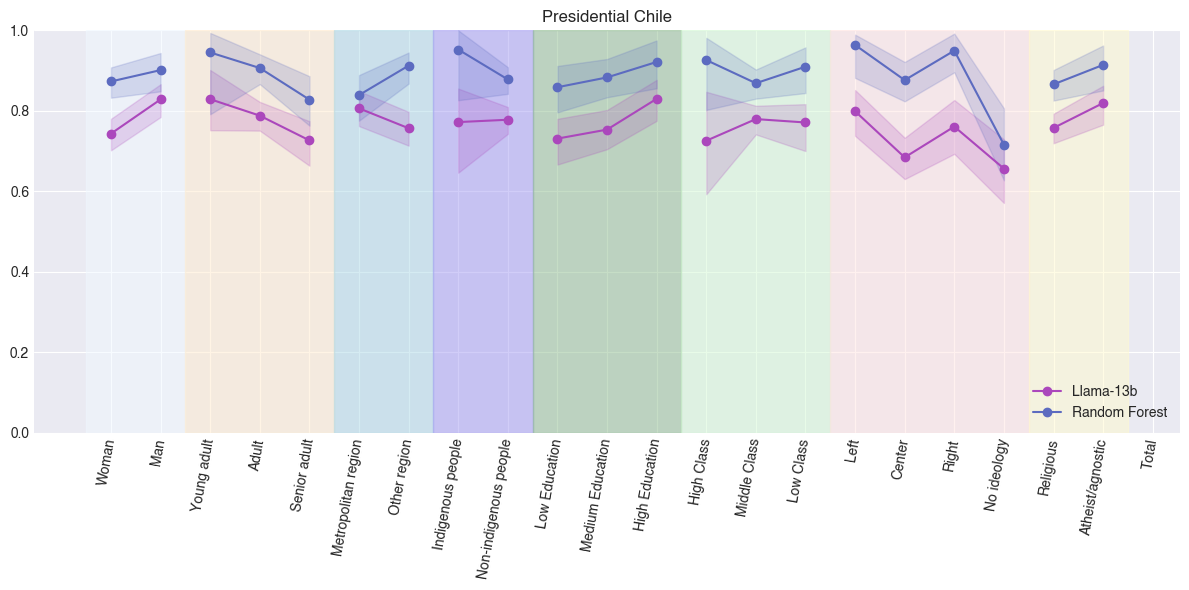

In [19]:
modelos = [llama_json_metrics, results_rf ]
modelos_nombres = ["Llama-13b", "Random Forest"]
sociodemographic_line_plot(modelos, modelos_colores, modelos_nombres, "Presidential Chile")

# Aggregated plots

## Aggregated across experiments (Llama-13b)

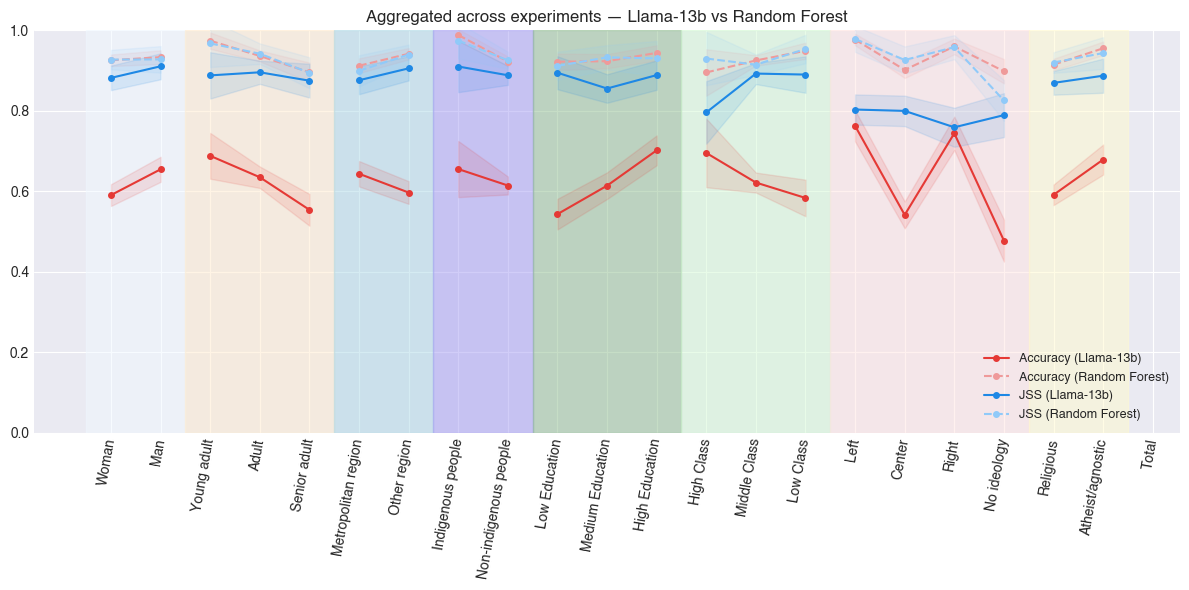

In [22]:
from matplotlib.transforms import ScaledTranslation

fig, ax = plt.subplots(figsize=(12, 6))
plt.style.use('https://github.com/dhaitz/matplotlib-stylesheets/raw/master/pacoty.mplstyle')

# Sociodemographic group ranges and background colors
grupos = {
    "Sexo": (0, 1),
    "Edad": (2, 4),
    "Región": (5, 6),
    "Pueblo originario": (7, 8),
    "Escolaridad": (9, 11),
    "GSE": (12, 14),
    "Ideología": (15, 18),
    "Religion": (19, 20),
}
colores_bg = {
    "Sexo": "#f0f8ff", "Edad": "#ffebcd", "Región": "#add8e6",
    "Pueblo originario": "#A49CF2", "Escolaridad": "#8FBC8F",
    "GSE": "#d3f8d3", "Ideología": "#ffe4e1", "Religion": "#fffacd",
}
for grupo, (inicio, fin) in grupos.items():
    ax.axvspan(inicio - 0.5, fin + 0.5, color=colores_bg[grupo], alpha=0.5)

# Models and metrics to plot
models = [
    {"data": agg_llama, "name": "Llama-13b"},
    {"data": agg_rf, "name": "Random Forest"},
]

metrics_to_plot = {
    "Accuracy": {"Llama-13b": "#e53935", "Random Forest": "#ef9a9a"},       # red tones
    "JSS": {"Llama-13b": "#1e88e5", "Random Forest": "#90caf9"},            # blue tones
}

for metric, model_colors in metrics_to_plot.items():
    ci_lo = f"{metric}_CI_lower"
    ci_hi = f"{metric}_CI_upper"
    for model in models:
        data = model["data"].copy()
        data = data[data['Group'] != "None (indigenous)"]
        data = data[data['Group'] != "None (education)"]
        data = data[data['Group'] != "No religion response"]
        data = data.reset_index(drop=True)

        color = model_colors[model["name"]]
        has_ci = ci_lo in data.columns and ci_hi in data.columns
        label = f"{metric} ({model['name']})"
        linestyle = '-' if model["name"] == "Llama-13b" else '--'

        for grupo, (inicio, fin) in grupos.items():
            x = list(range(inicio, fin + 1))
            y = data[metric].iloc[inicio:fin + 1].astype(float)
            ax.plot(x, y, linestyle + 'o', label=label if grupo == "Sexo" else "",
                    color=color, markersize=4)
            if has_ci:
                y_lo = data[ci_lo].iloc[inicio:fin + 1].astype(float)
                y_hi = data[ci_hi].iloc[inicio:fin + 1].astype(float)
                ax.fill_between(x, y_lo, y_hi, color=color, alpha=0.12)

# X-axis labels from filtered data
data_labels = agg_llama[agg_llama['Group'] != "None (indigenous)"]
data_labels = data_labels[data_labels['Group'] != "None (education)"]
data_labels = data_labels[data_labels['Group'] != "No religion response"]
data_labels = data_labels.reset_index(drop=True)

ax.set_ylim(0, 1)
ax.set_xticks(range(len(data_labels["Group"])))
ax.set_xticklabels(data_labels["Group"], rotation=80, ha='right')
ax.legend(loc='lower right', fontsize=9)
ax.set_title("Aggregated across experiments — Llama-13b vs Random Forest")

for label in ax.get_xticklabels():
    offset = ScaledTranslation(5/72, 0, fig.dpi_scale_trans)
    label.set_transform(label.get_transform() + offset)

plt.tight_layout()
plt.show()

In [23]:
# Compute ratio Llama / RF with Delta Method CIs
ratio_df = agg_llama[["Group"]].copy()

for metric in ["Accuracy", "JSS"]:
    ci_lo = f"{metric}_CI_lower"
    ci_hi = f"{metric}_CI_upper"

    x = agg_llama[metric].astype(float)           # Llama
    y = agg_rf[metric].astype(float)               # RF
    se_x = (agg_llama[ci_hi].astype(float) - agg_llama[ci_lo].astype(float)) / (2 * z)
    se_y = (agg_rf[ci_hi].astype(float) - agg_rf[ci_lo].astype(float)) / (2 * z)

    r = x / y
    se_r = r * np.sqrt((se_x / x)**2 + (se_y / y)**2)

    ratio_df[metric] = r
    ratio_df[f"{metric}_CI_lower"] = r - z * se_r
    ratio_df[f"{metric}_CI_upper"] = r + z * se_r

ratio_df

,Group,Accuracy,Accuracy_CI_lower,Accuracy_CI_upper,JSS,JSS_CI_lower,JSS_CI_upper
0,Woman,0.637979,0.607187,0.668772,0.950963,0.909773,0.992153
1,Man,0.701299,0.665525,0.737072,0.981533,0.932273,1.030793
2,Young adult,0.706140,0.645988,0.766293,0.917823,0.836292,0.999354
3,Adult,0.678013,0.647884,0.708141,0.950944,0.910865,0.991022
4,Senior adult,0.618321,0.571221,0.665421,0.978041,0.914943,1.041139
5,Metropolitan region,0.705584,0.668235,0.742932,0.973918,0.916988,1.030848
6,Other region,0.633682,0.602255,0.665109,0.963377,0.922738,1.004015
7,Indigenous people,0.662791,0.591526,0.734055,0.933844,0.855579,1.012110
8,Non-indigenous people,0.665861,0.640016,0.691706,0.959958,0.925889,0.994027
9,None (indigenous),0.500000,0.257044,0.742956,0.794864,0.565544,1.024184


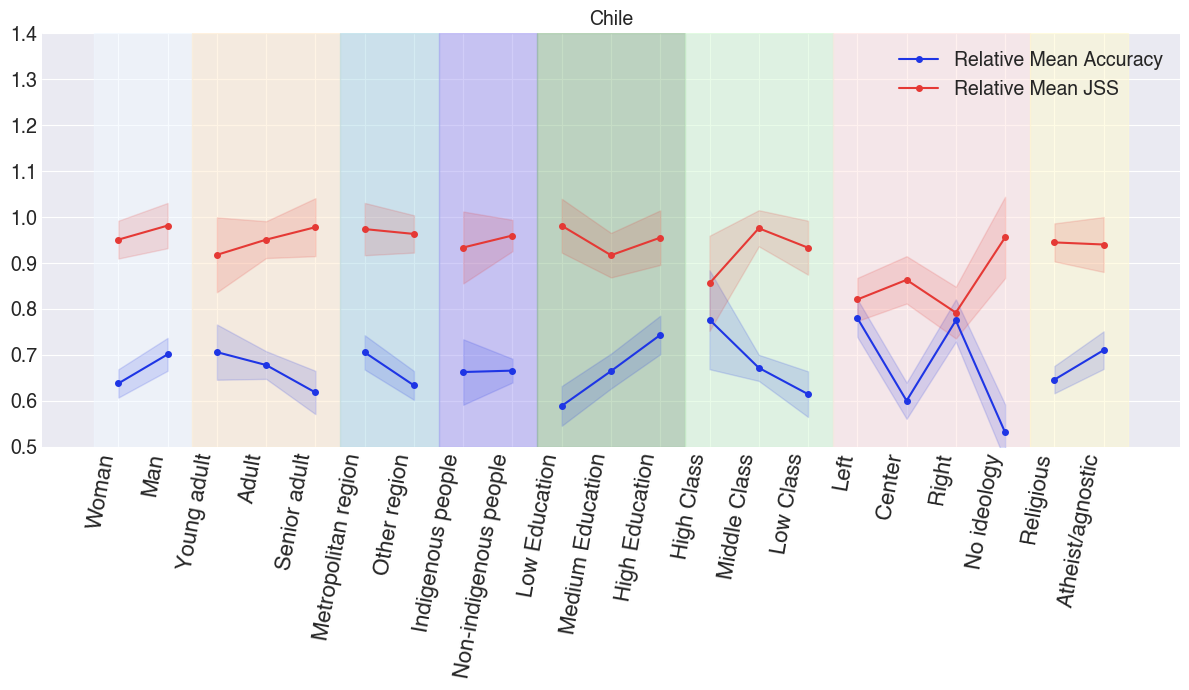

In [24]:
from matplotlib.transforms import ScaledTranslation

fig, ax = plt.subplots(figsize=(12, 7))
plt.style.use('https://github.com/dhaitz/matplotlib-stylesheets/raw/master/pacoty.mplstyle')

# Sociodemographic group backgrounds (reuse existing pattern)
grupos = {
    "Sexo": (0, 1), "Edad": (2, 4), "Región": (5, 6),
    "Pueblo originario": (7, 8), "Escolaridad": (9, 11),
    "GSE": (12, 14), "Ideología": (15, 18), "Religion": (19, 20),
}
colores_bg = {
    "Sexo": "#f0f8ff", "Edad": "#ffebcd", "Región": "#add8e6",
    "Pueblo originario": "#A49CF2", "Escolaridad": "#8FBC8F",
    "GSE": "#d3f8d3", "Ideología": "#ffe4e1", "Religion": "#fffacd",
}
for grupo, (inicio, fin) in grupos.items():
    ax.axvspan(inicio - 0.5, fin + 0.5, color=colores_bg[grupo], alpha=0.5)

# Filter rows
data = ratio_df[ratio_df['Group'] != "None (indigenous)"]
data = data[data['Group'] != "None (education)"]
data = data[data['Group'] != "No religion response"]
data = data[data['Group'] != "Total"]
data = data.reset_index(drop=True)

# Reference line at ratio = 1
# ax.axhline(y=1.0, color='gray', linestyle=':', linewidth=1, label='Ratio = 1')

# Plot each metric
metric_colors = {"Accuracy": "#1e35e5", "JSS":  "#e53935"}
legend_names = {"Accuracy": "Relative Mean Accuracy", "JSS": "Relative Mean JSS"}
for metric, color in metric_colors.items():
    ci_lo = f"{metric}_CI_lower"
    ci_hi = f"{metric}_CI_upper"
    for grupo, (inicio, fin) in grupos.items():
        x = list(range(inicio, fin + 1))
        y = data[metric].iloc[inicio:fin + 1].astype(float)
        ax.plot(x, y, '-o', label=legend_names[metric] if grupo == "Sexo" else "",
                color=color, markersize=4)
        y_lo = data[ci_lo].iloc[inicio:fin + 1].astype(float)
        y_hi = data[ci_hi].iloc[inicio:fin + 1].astype(float)
        ax.fill_between(x, y_lo, y_hi, color=color, alpha=0.15)

ax.set_ylim(bottom=0.5, top=1.4)
ax.set_xticks(range(len(data["Group"])))
ax.set_xticklabels(data["Group"], rotation=80, ha='right', fontsize=16)
ax.legend(loc='upper right', fontsize=14)
plt.yticks(fontsize=14)
# ax.set_ylabel("Ratio (Llama / Random Forest)")
ax.set_title("Chile", fontsize=14)



plt.tight_layout()
fig.savefig("ratio_plot_chile.pdf", bbox_inches='tight')
plt.show()

In [ ]:
## Aggregated Accuracy and JSS plots — all models

import scipy.stats as st
from matplotlib.transforms import ScaledTranslation

z = st.norm.ppf(0.975)
metric_cols = ["JSD", "Accuracy", "Harmonic Mean", "JSS"]

def aggregate_model_metrics(all_metrics_list):
    """Average metrics across experiments and combine CIs."""
    agg = all_metrics_list[0][["Group"]].copy()
    for col in metric_cols:
        ci_lo_col = f"{col}_CI_lower"
        ci_hi_col = f"{col}_CI_upper"
        means, ses = [], []
        for m in all_metrics_list:
            means.append(m[col].astype(float))
            ses.append((m[ci_hi_col].astype(float) - m[ci_lo_col].astype(float)) / (2 * z))
        mean_vals = sum(means) / len(means)
        se_combined = np.sqrt(sum(se**2 for se in ses)) / len(ses)
        agg[col] = mean_vals
        agg[ci_lo_col] = mean_vals - z * se_combined
        agg[ci_hi_col] = mean_vals + z * se_combined
    return agg

# --- Aggregate GPT-3.5 ---
all_metrics_gpt3 = []
for exp in experiments:
    route = f"../results_dataframes/{exp['name']}/"
    df_tmp = pd.read_csv(route + f"{exp['name']}_chile_chatgpt3_cot.csv")
    data_tmp = data_charger(route + "exp_inputs_filtrado.csv", df_tmp, exp["d"], prompt_type='cot')
    m = metrics_dataset_gen_chile(data_tmp, exp["column_to_predict"], n_bootstrap=1000, random_seed=42)
    m = m[m['Group'] != 'total']
    all_metrics_gpt3.append(m.reset_index(drop=True))
agg_gpt3 = aggregate_model_metrics(all_metrics_gpt3)

# --- Aggregate GPT-4 ---
all_metrics_gpt4 = []
for exp in experiments:
    route = f"../results_dataframes/{exp['name']}/"
    df_tmp = pd.read_csv(route + f"{exp['name']}_chile_chatgpt4_cot.csv")
    data_tmp = data_charger(route + "exp_inputs_filtrado.csv", df_tmp, exp["d"], prompt_type='cot')
    m = metrics_dataset_gen_chile(data_tmp, exp["column_to_predict"], n_bootstrap=1000, random_seed=42)
    m = m[m['Group'] != 'total']
    all_metrics_gpt4.append(m.reset_index(drop=True))
agg_gpt4 = aggregate_model_metrics(all_metrics_gpt4)

# --- Aggregate Mistral ---
all_metrics_mistral = []
for exp in experiments:
    route = f"../results_dataframes/{exp['name']}/"
    data_tmp = data_charger(route + "exp_inputs_filtrado.csv", route + f"{exp['name']}_chile_mistral_cot.jsonl", exp["d"], prompt_type='cot')
    m = metrics_dataset_gen_chile(data_tmp, exp["column_to_predict"], n_bootstrap=1000, random_seed=42)
    m = m[m['Group'] != 'total']
    all_metrics_mistral.append(m.reset_index(drop=True))
agg_mistral = aggregate_model_metrics(all_metrics_mistral)

# # --- Aggregate T-zero ---
# all_metrics_t0 = []
# for exp in experiments:
#     route = f"../results_dataframes/{exp['name']}/"
#     data_tmp = data_charger(route + "exp_inputs_filtrado.csv", route + f"{exp['name']}_chile_t0_cot.jsonl", exp["d"], prompt_type='cot', is_t0=True)
#     m = metrics_dataset_gen_chile(data_tmp, exp["column_to_predict"], n_bootstrap=1000, random_seed=42)
#     m = m[m['Group'] != 'total']
#     all_metrics_t0.append(m.reset_index(drop=True))
# agg_t0 = aggregate_model_metrics(all_metrics_t0)

# agg_llama and agg_rf already computed in previous cells

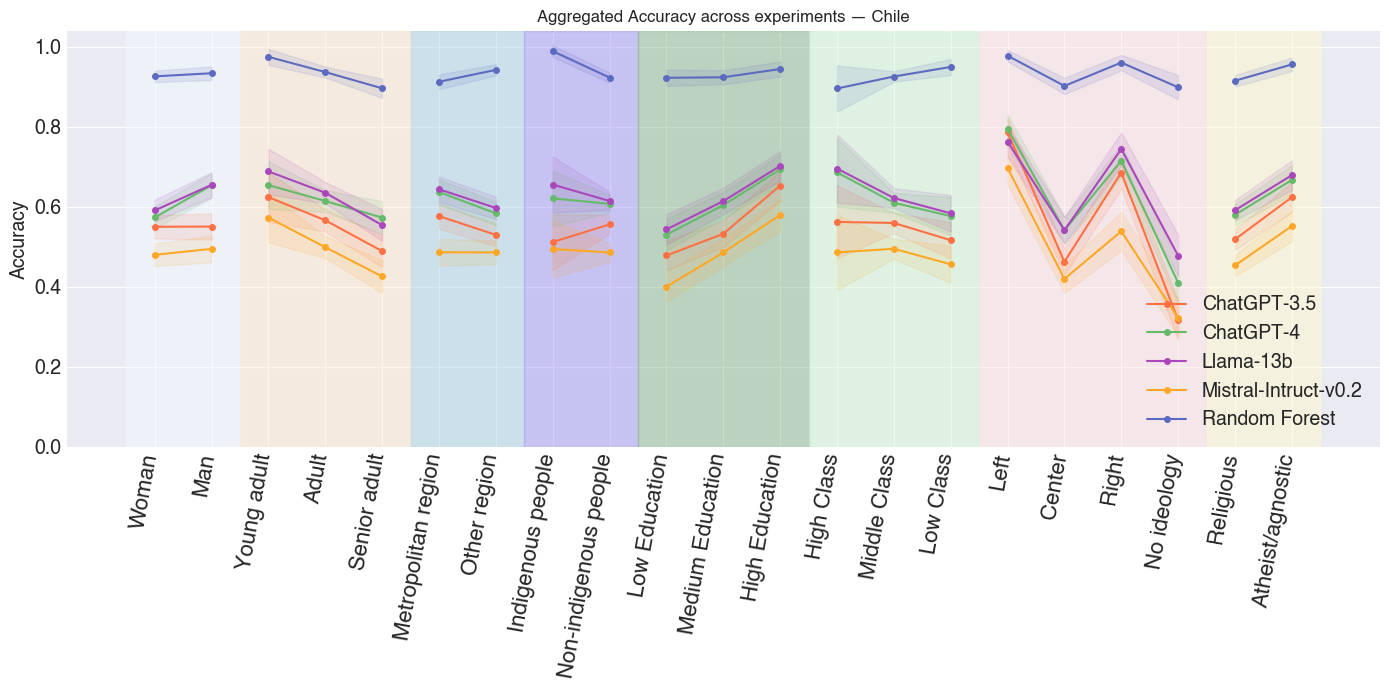

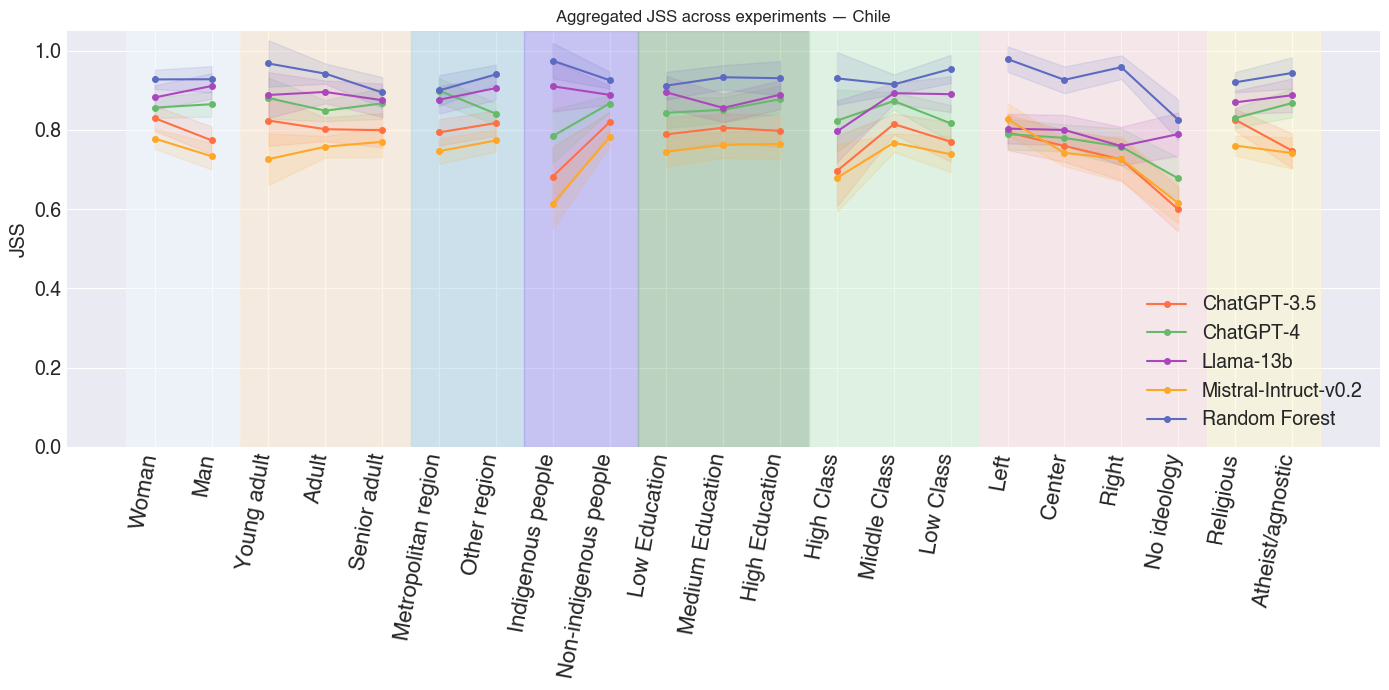

In [58]:


# --- Plot Accuracy and JSS for all 6 models ---
all_agg_models = [
    (agg_gpt3, "ChatGPT-3.5"),
    (agg_gpt4, "ChatGPT-4"),
    (agg_llama, "Llama-13b"),
    (agg_mistral, "Mistral-Intruct-v0.2"),
    # (agg_t0, "T-zero"),
    (agg_rf, "Random Forest"),
]

grupos = {
    "Sexo": (0, 1), "Edad": (2, 4), "Región": (5, 6),
    "Pueblo originario": (7, 8), "Escolaridad": (9, 11),
    "GSE": (12, 14), "Ideología": (15, 18), "Religion": (19, 20),
}
colores_bg = {
    "Sexo": "#f0f8ff", "Edad": "#ffebcd", "Región": "#add8e6",
    "Pueblo originario": "#A49CF2", "Escolaridad": "#8FBC8F",
    "GSE": "#d3f8d3", "Ideología": "#ffe4e1", "Religion": "#fffacd",
}
exclude_groups = ["None (indigenous)", "None (education)", "No religion response", "Total"]

for metric in ["Accuracy", "JSS"]:
    fig, ax = plt.subplots(figsize=(14, 7))
    plt.style.use('https://github.com/dhaitz/matplotlib-stylesheets/raw/master/pacoty.mplstyle')

    for grupo, (inicio, fin) in grupos.items():
        ax.axvspan(inicio - 0.5, fin + 0.5, color=colores_bg[grupo], alpha=0.5)

    ci_lo_col = f"{metric}_CI_lower"
    ci_hi_col = f"{metric}_CI_upper"

    for model_data, model_name in all_agg_models:
        data = model_data.copy()
        data = data[~data['Group'].isin(exclude_groups)]
        data = data.reset_index(drop=True)
        has_ci = ci_lo_col in data.columns and ci_hi_col in data.columns
        color = modelos_colores[model_name]
        for grupo, (inicio, fin) in grupos.items():
            x = list(range(inicio, fin + 1))
            y = data[metric].iloc[inicio:fin + 1].astype(float)
            ax.plot(x, y, '-o', label=model_name if grupo == "Sexo" else "",
                    color=color, markersize=4)
            if has_ci:
                y_lo = data[ci_lo_col].iloc[inicio:fin + 1].astype(float)
                y_hi = data[ci_hi_col].iloc[inicio:fin + 1].astype(float)
                ax.fill_between(x, y_lo, y_hi, color=color, alpha=0.12)

    ref_data = all_agg_models[0][0].copy()
    ref_data = ref_data[~ref_data['Group'].isin(exclude_groups)]
    ref_data = ref_data.reset_index(drop=True)

    ax.set_ylim(bottom = 0.0)
    ax.set_xticks(range(len(ref_data["Group"])))
    ax.set_xticklabels(ref_data["Group"], rotation=80, ha='right', fontsize=16)
    ax.legend(loc='lower right', fontsize=14)
    ax.set_title(f"Aggregated {metric} across experiments — Chile")
    ax.set_ylabel(metric,  fontsize=14)
    plt.yticks(fontsize=14)

    for label in ax.get_xticklabels():
        offset = ScaledTranslation(5/72, 0, fig.dpi_scale_trans)
        label.set_transform(label.get_transform() + offset)

    plt.tight_layout()
    fig.savefig(f"aggregated_{metric}_chile.pdf", bbox_inches='tight')
    plt.show()